In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.columns.tolist()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [4]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Basic Statistics ===')
df.describe()

=== Missing Values ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

=== Data Types ===
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

=== Basic Statistics ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Drop rows with missing values
df.dropna(inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Encode any text/categorical columns to numbers
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f'Encoded column: {col}')

df.reset_index(drop=True, inplace=True)
print('\nCleaned shape:', df.shape)
df.head()

Encoded column: Sex
Encoded column: ChestPainType
Encoded column: RestingECG
Encoded column: ExerciseAngina
Encoded column: ST_Slope

Cleaned shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


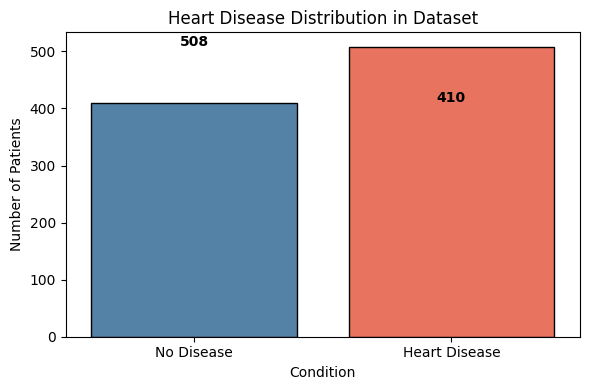


No Disease    : 410
Heart Disease : 508


In [7]:
# 'target' column: 1 = Heart Disease, 0 = No Disease
target_col = 'HeartDisease'   # change if your column is named differently

counts = df[target_col].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values,
            palette=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.title('Heart Disease Distribution in Dataset')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nNo Disease    : {counts[0]}')
print(f'Heart Disease : {counts[1]}')

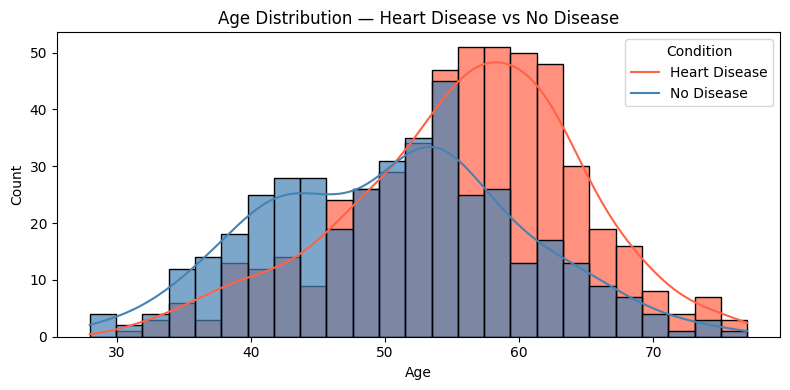

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue=target_col, bins=25,
             kde=True, palette={0: 'steelblue', 1: 'tomato'}, alpha=0.7)
plt.title('Age Distribution — Heart Disease vs No Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Condition', labels=['Heart Disease', 'No Disease'])
plt.tight_layout()
plt.show()

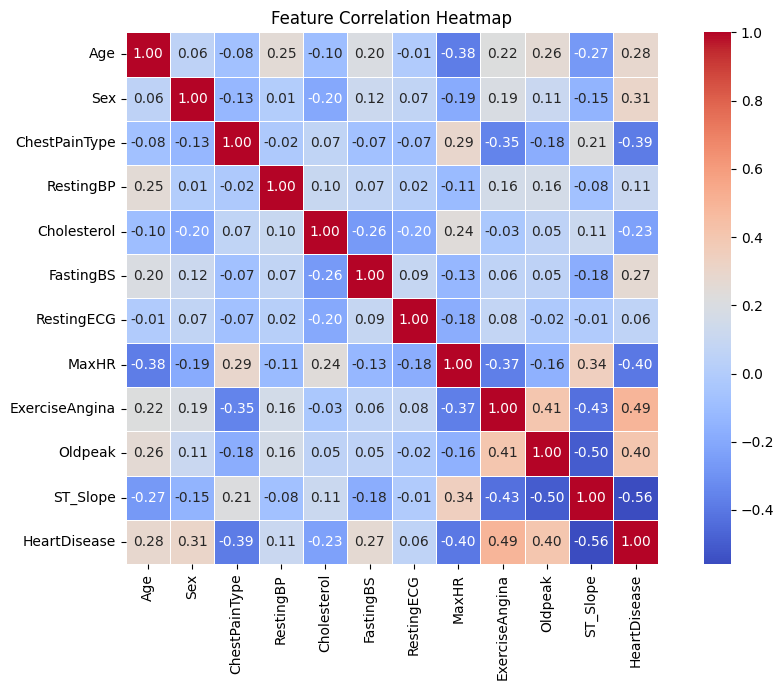

In [9]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
target_col = 'HeartDisease'   # change if your target column has a different name

X = df.drop(columns=[target_col])   # all columns except target = features
y = df[target_col]                  # target column = what we want to predict

print('Features (X) shape:', X.shape)
print('Target  (y) shape :', y.shape)
print('\nFeature columns:')
print(X.columns.tolist())

Features (X) shape: (918, 11)
Target  (y) shape : (918,)

Feature columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% data for testing, 80% for training
    random_state=42,    # ensures same split every run
    stratify=y          # keeps class ratio same in both splits
)

print('Training samples :', X_train.shape[0])
print('Testing  samples :', X_test.shape[0])

Training samples : 734
Testing  samples : 184


In [12]:
dt = DecisionTreeClassifier(
    max_depth=5,          # limits tree depth to prevent overfitting
    min_samples_split=10, # minimum samples needed to split a node
    min_samples_leaf=5,   # minimum samples required at a leaf node
    random_state=42
)

dt.fit(X_train, y_train)
print('Decision Tree trained successfully!')
print(f'\nTree depth    : {dt.get_depth()}')
print(f'Total leaves  : {dt.get_n_leaves()}')

Decision Tree trained successfully!

Tree depth    : 5
Total leaves  : 27


In [13]:
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
                             target_names=['No Disease', 'Heart Disease']))

Accuracy: 78.80%

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.75      0.78      0.77        82
Heart Disease       0.82      0.79      0.81       102

     accuracy                           0.79       184
    macro avg       0.79      0.79      0.79       184
 weighted avg       0.79      0.79      0.79       184



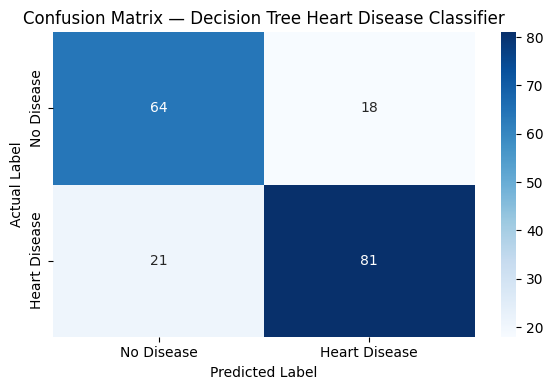


True  Negatives  (Correctly predicted No Disease)  : 64
False Positives  (No Disease predicted as Disease) : 18
False Negatives  (Disease missed by model)         : 21
True  Positives  (Correctly predicted Disease)     : 81


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — Decision Tree Heart Disease Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue  Negatives  (Correctly predicted No Disease)  : {tn}')
print(f'False Positives  (No Disease predicted as Disease) : {fp}')
print(f'False Negatives  (Disease missed by model)         : {fn}')
print(f'True  Positives  (Correctly predicted Disease)     : {tp}')

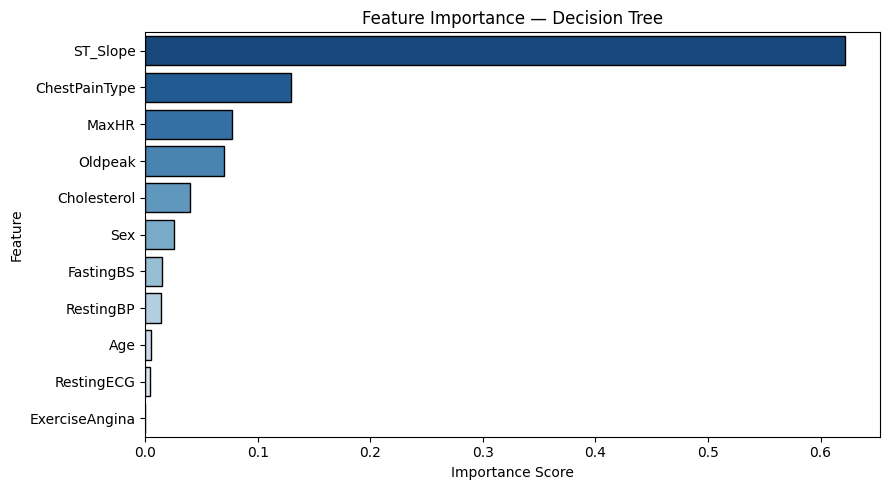


Top 5 most important features:
ST_Slope         0.621750
ChestPainType    0.129513
MaxHR            0.076844
Oldpeak          0.069517
Cholesterol      0.039747
dtype: float64


In [15]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index,
            palette='Blues_r', edgecolor='black')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.head())

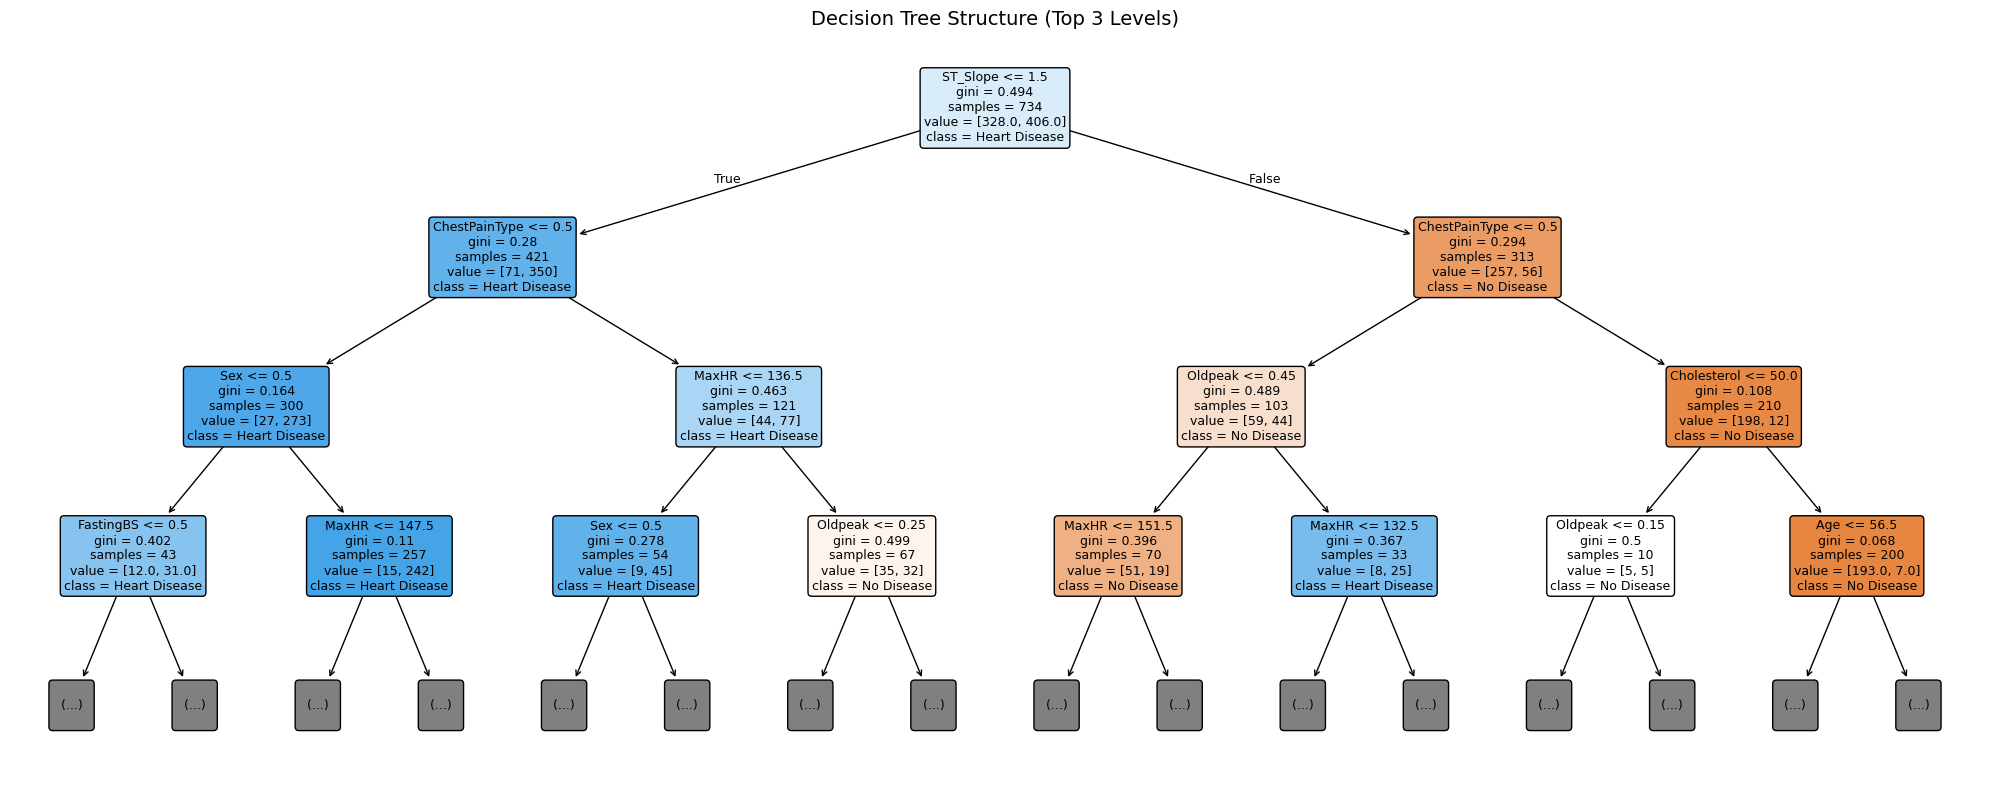

In [16]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,        # colour nodes by class
    rounded=True,       # rounded box corners
    fontsize=9,
    max_depth=3         # show top 3 levels for readability
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# Predict for a single new patient — use values matching your dataset columns
# Replace values below with realistic numbers from your dataset
sample_patient = pd.DataFrame([X_test.iloc[0]])   # takes first test row as example

prediction = dt.predict(sample_patient)[0]
probability = dt.predict_proba(sample_patient)[0]

print('=== Single Patient Prediction ===')
print(f'Patient features:\n{sample_patient.to_string(index=False)}')
print(f'\nPrediction  : {"Heart Disease" if prediction == 1 else "No Disease"}')
print(f'Confidence  : {max(probability) * 100:.1f}%')

# ── Final Summary ──────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print('\n' + '='*45)
print('           FINAL MODEL SUMMARY')
print('='*45)
print(f'  Algorithm          : Decision Tree Classifier')
print(f'  Accuracy           : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Disease Recall     : {tp/(tp+fn)*100:.2f}%  (sick patients caught)')
print(f'  Healthy Recall     : {tn/(tn+fp)*100:.2f}%  (healthy patients correct)')
print(f'  True  Positives    : {tp}')
print(f'  True  Negatives    : {tn}')
print(f'  False Positives    : {fp}')
print(f'  False Negatives    : {fn}')
print('='*45)

=== Single Patient Prediction ===
Patient features:
 Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  MaxHR  ExerciseAngina  Oldpeak  ST_Slope
46.0  1.0            0.0      115.0          0.0        0.0         1.0  113.0             1.0      1.5       1.0

Prediction  : Heart Disease
Confidence  : 99.1%

           FINAL MODEL SUMMARY
  Algorithm          : Decision Tree Classifier
  Accuracy           : 78.80%
  Disease Recall     : 79.41%  (sick patients caught)
  Healthy Recall     : 78.05%  (healthy patients correct)
  True  Positives    : 81
  True  Negatives    : 64
  False Positives    : 18
  False Negatives    : 21
